<a href="https://colab.research.google.com/github/bhavyaanil07/ACM-SIG-AI-PROJECTS-AND-IMPLEMENTATIONS/blob/main/LINEAR-REGRESSION/LINEARREGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
print("pandas library imported.")

pandas library imported.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
%matplotlib inline

In [ ]:
import pandas as pd
df = pd.read_csv('/content/flights.csv')
df.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


In [ ]:
print("Missing values before handling:")
df.isnull().sum()

Missing values before handling:


,0
id,0
year,0
month,0
day,0
dep_time,8255
sched_dep_time,0
dep_delay,8255
arr_time,8713
sched_arr_time,0
arr_delay,9430


In [ ]:
df.fillna({'dep_time': df['dep_time'].median()}, inplace=True)
df.fillna({'arr_time': df['arr_time'].median(),'arr_delay': df['arr_delay'].median(),'air_time': df['air_time'].median(),'dep_delay': df['dep_delay'].median(),'tailnum': 'Unknown'}, inplace=True)
print("Missing values after handling:")
df.isnull().sum()

Missing values after handling:


,0
id,0
year,0
month,0
day,0
dep_time,0
sched_dep_time,0
dep_delay,0
arr_time,0
sched_arr_time,0
arr_delay,0


In [ ]:
import pandas as pd

# Read your dataset (replace with correct path if needed)
df = pd.read_csv('flights.csv')

# Only one-hot encode columns with low cardinality
df_encoded = pd.get_dummies(df, columns=['origin', 'dest'], drop_first=True, dtype=int)
df_encoded.head()


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,dest_SNA,dest_SRQ,dest_STL,dest_STT,dest_SYR,dest_TPA,dest_TUL,dest_TVC,dest_TYS,dest_XNA
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,0,0,0,0,0,0,0,0,0,0
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,0,0,0,0,0,0,0,0,0,0
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,0,0,0,0,0,0,0,0,0,0
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,0,0,0,0,0,0,0,0,0,0
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("Descriptive statistics for the DataFrame:")
df.describe()

Descriptive statistics for the DataFrame:


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
count,336776.000000,336776.0,336776.000000,336776.000000,328521.000000,336776.000000,328521.000000,328063.000000,336776.000000,327346.000000,336776.000000,327346.000000,336776.000000,336776.000000,336776.000000
mean,168387.500000,2013.0,6.548510,15.710787,1349.109947,1344.254840,12.639070,1502.054999,1536.380220,6.895377,1971.923620,150.686460,1039.912604,13.180247,26.230100
std,97219.001466,0.0,3.414457,8.768607,488.281791,467.335756,40.210061,533.264132,497.457142,44.633292,1632.471938,93.688305,733.233033,4.661316,19.300846
min,0.000000,2013.0,1.000000,1.000000,1.000000,106.000000,-43.000000,1.000000,1.000000,-86.000000,1.000000,20.000000,17.000000,1.000000,0.000000
25%,84193.750000,2013.0,4.000000,8.000000,907.000000,906.000000,-5.000000,1104.000000,1124.000000,-17.000000,553.000000,82.000000,502.000000,9.000000,8.000000
50%,168387.500000,2013.0,7.000000,16.000000,1401.000000,1359.000000,-2.000000,1535.000000,1556.000000,-5.000000,1496.000000,129.000000,872.000000,13.000000,29.000000
75%,252581.250000,2013.0,10.000000,23.000000,1744.000000,1729.000000,11.000000,1940.000000,1945.000000,14.000000,3465.000000,192.000000,1389.000000,17.000000,44.000000
max,336775.000000,2013.0,12.000000,31.000000,2400.000000,2359.000000,1301.000000,2400.000000,2359.000000,1272.000000,8500.000000,695.000000,4983.000000,23.000000,59.000000


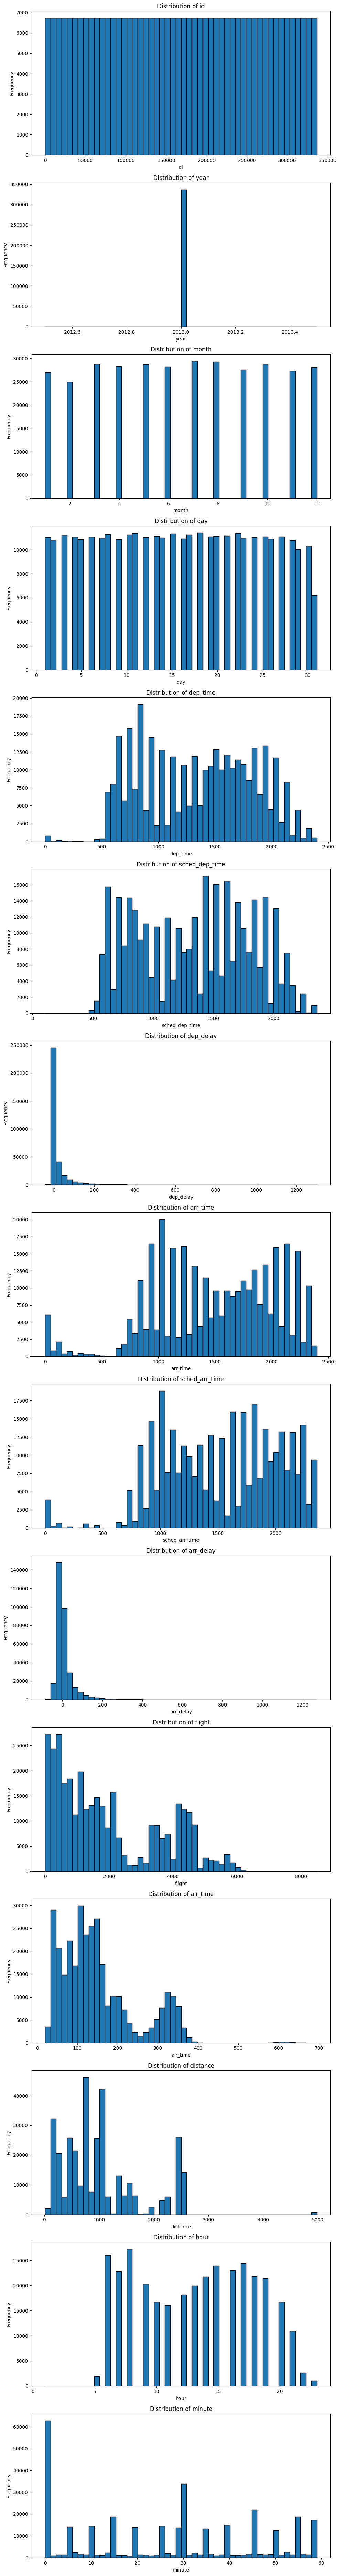

Histograms for numerical features displayed.


In [ ]:
import matplotlib.pyplot as plt

# Identify numerical columns for histograms (excluding one-hot encoded columns for now if they are just 0s and 1s)
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
# Exclude binary one-hot encoded columns from this particular visualization if they are not truly continuous features
# Keeping them in for now as they might have interesting distributions

fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=1, figsize=(10, 5 * len(numerical_cols)))
axes = axes.flatten() # Flatten in case of single row/column

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Histograms for numerical features displayed.")

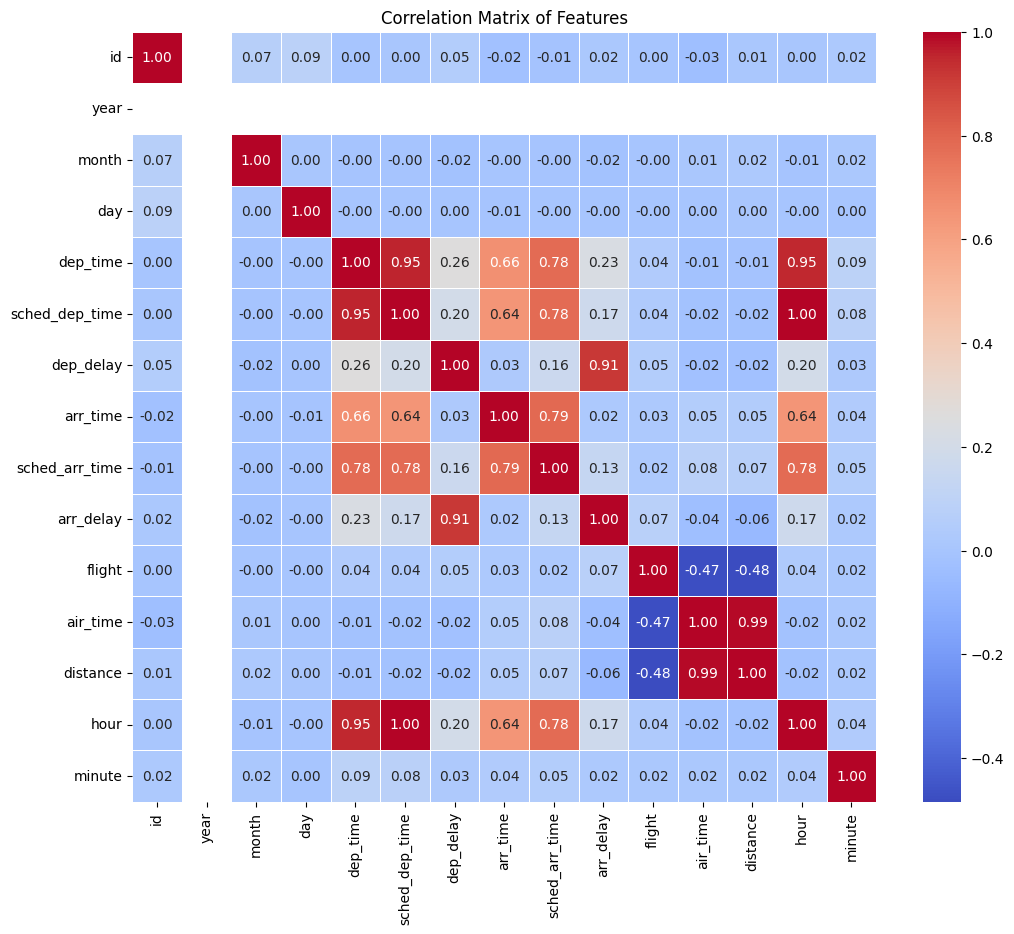

Correlation matrix heatmap displayed.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()
print("Correlation matrix heatmap displayed.")

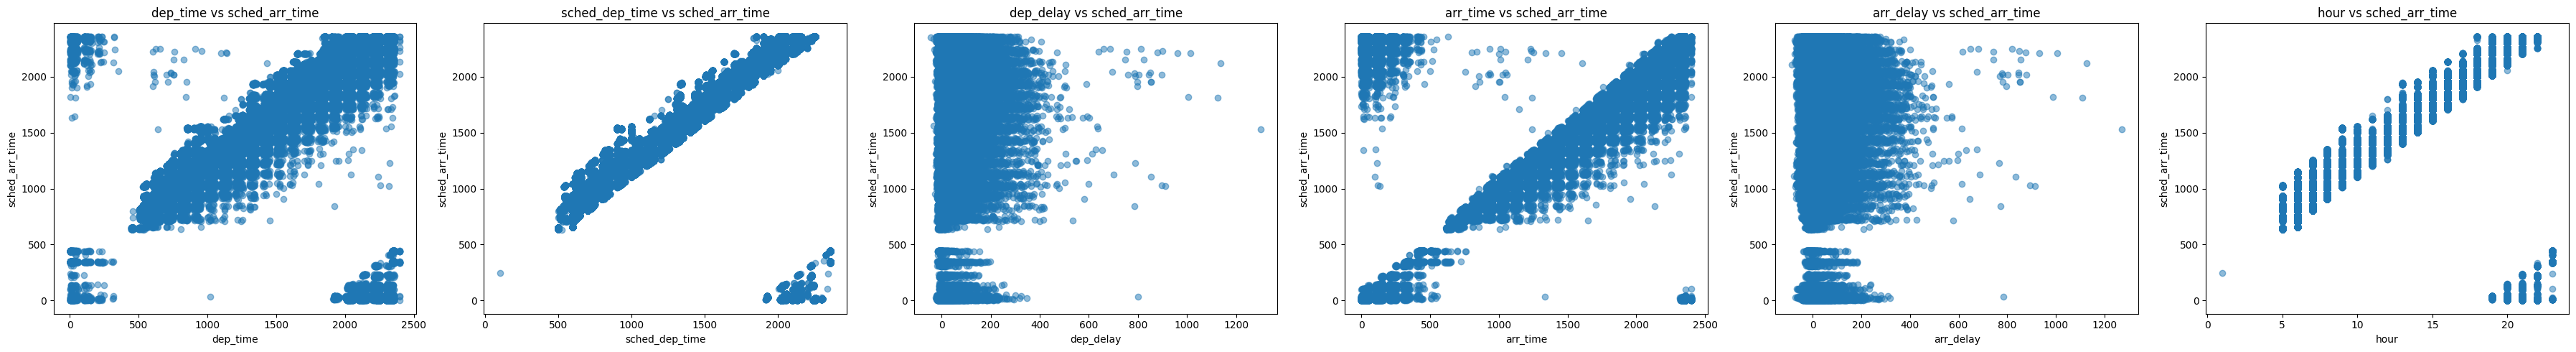

Scatter plots for key features vs sched_arr_time displayed.


In [ ]:
import matplotlib.pyplot as plt

features = ['dep_time', 'sched_dep_time', 'dep_delay','arr_time','arr_delay','hour']
target = 'sched_arr_time'

fig, axes = plt.subplots(nrows=1, ncols=len(features), figsize=(6 * len(features), 5))

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df[target], alpha=0.5)
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()
print("Scatter plots for key features vs sched_arr_time displayed.")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Identify categorical columns for one-hot encoding
cols_to_encode = ['carrier', 'origin', 'dest']

# Identify columns to drop (e.g., datetime strings, high cardinality identifiers)
cols_to_drop = ['time_hour', 'tailnum', 'name']

# Create a copy of df to avoid modifying the original DataFrame directly
df_model = df.copy()

# Re-apply missing value imputation for numerical columns
# This ensures that numerical features do not contain NaNs before model training,
# especially if 'df' was reloaded in a previous cell without re-applying imputation.
df_model['dep_time'].fillna(df_model['dep_time'].median(), inplace=True)
df_model['arr_time'].fillna(df_model['arr_time'].median(), inplace=True)
df_model['arr_delay'].fillna(df_model['arr_delay'].median(), inplace=True)
df_model['air_time'].fillna(df_model['air_time'].median(), inplace=True)
df_model['dep_delay'].fillna(df_model['dep_delay'].median(), inplace=True)

# Drop columns not needed for modeling
df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

# One-hot encode the selected categorical columns
df_processed = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True, dtype=int)

# Define features (X) and target variable (y)
# Ensure 'sched_arr_time' is not in X after one-hot encoding
X = df_processed.drop('sched_arr_time', axis=1)
y = df_processed['sched_arr_time']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Dataset split into training and testing sets.")
print("Linear Regression model initialized and trained.")

Dataset split into training and testing sets.
Linear Regression model initialized and trained.


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f"Model Performance on Test Set:")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model Performance on Test Set:
R-squared: 0.7767
Mean Squared Error (MSE): 55489.08
Root Mean Squared Error (RMSE): 235.56


In [ ]:
print("Descriptive statistics for the DataFrame:")
df.describe()

Descriptive statistics for the DataFrame:


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
count,336776.000000,336776.0,336776.000000,336776.000000,328521.000000,336776.000000,328521.000000,328063.000000,336776.000000,327346.000000,336776.000000,327346.000000,336776.000000,336776.000000,336776.000000
mean,168387.500000,2013.0,6.548510,15.710787,1349.109947,1344.254840,12.639070,1502.054999,1536.380220,6.895377,1971.923620,150.686460,1039.912604,13.180247,26.230100
std,97219.001466,0.0,3.414457,8.768607,488.281791,467.335756,40.210061,533.264132,497.457142,44.633292,1632.471938,93.688305,733.233033,4.661316,19.300846
min,0.000000,2013.0,1.000000,1.000000,1.000000,106.000000,-43.000000,1.000000,1.000000,-86.000000,1.000000,20.000000,17.000000,1.000000,0.000000
25%,84193.750000,2013.0,4.000000,8.000000,907.000000,906.000000,-5.000000,1104.000000,1124.000000,-17.000000,553.000000,82.000000,502.000000,9.000000,8.000000
50%,168387.500000,2013.0,7.000000,16.000000,1401.000000,1359.000000,-2.000000,1535.000000,1556.000000,-5.000000,1496.000000,129.000000,872.000000,13.000000,29.000000
75%,252581.250000,2013.0,10.000000,23.000000,1744.000000,1729.000000,11.000000,1940.000000,1945.000000,14.000000,3465.000000,192.000000,1389.000000,17.000000,44.000000
max,336775.000000,2013.0,12.000000,31.000000,2400.000000,2359.000000,1301.000000,2400.000000,2359.000000,1272.000000,8500.000000,695.000000,4983.000000,23.000000,59.000000


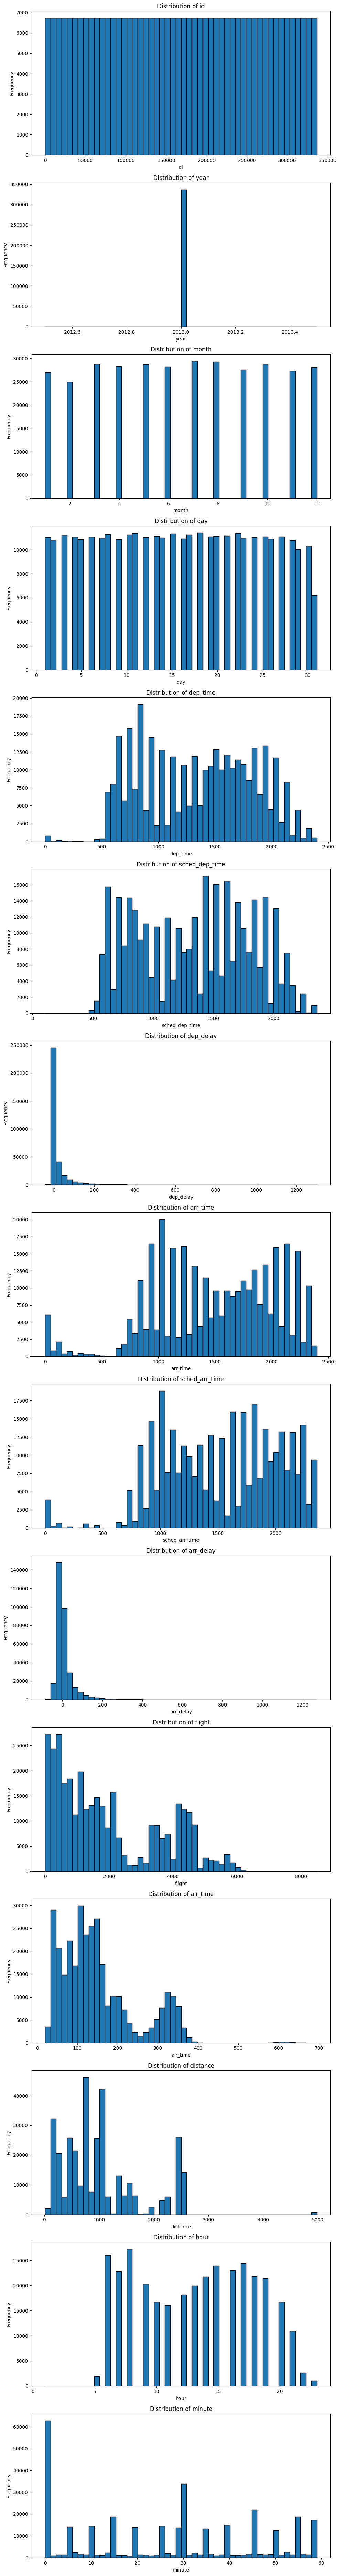

Histograms for numerical features displayed.


In [ ]:
import matplotlib.pyplot as plt

# Identify numerical columns for histograms
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=1, figsize=(10, 5 * len(numerical_cols)))
axes = axes.flatten() # Flatten in case of single row/column

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Histograms for numerical features displayed.")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd # Ensure pandas is imported if not already in this cell's scope

# Identify categorical columns for one-hot encoding
cols_to_encode = ['carrier', 'origin', 'dest']

# Identify columns to drop (e.g., datetime strings, high cardinality identifiers)
cols_to_drop = ['time_hour', 'tailnum', 'name']

# Create a copy of df to avoid modifying the original DataFrame directly for this modeling task
df_model = df.copy()

# Re-apply missing value imputation for numerical columns (as df might have been reset or not fully processed)
# This ensures that numerical features do not contain NaNs before model training.
# Based on the notebook state, these were already handled in cell 1X2tDF9zKh-Z, but re-including for completeness within this cell's context.
df_model['dep_time'].fillna(df_model['dep_time'].median(), inplace=True)
df_model['arr_time'].fillna(df_model['arr_time'].median(), inplace=True)
df_model['arr_delay'].fillna(df_model['arr_delay'].median(), inplace=True)
df_model['air_time'].fillna(df_model['air_time'].median(), inplace=True)
df_model['dep_delay'].fillna(df_model['dep_delay'].median(), inplace=True)

# Drop columns not needed for modeling
df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

# One-hot encode the selected categorical columns
df_processed = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True, dtype=int)

# Define features (X) and target variable (y)
# Ensure 'sched_arr_time' is not in X after one-hot encoding
X = df_processed.drop('sched_arr_time', axis=1)
y = df_processed['sched_arr_time']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Dataset split into training and testing sets.")
print("Linear Regression model initialized and trained.")

Dataset split into training and testing sets.
Linear Regression model initialized and trained.


In [ ]:
from sklearn.metrics import r2_score , mean_squared_error
import numpy as np
r2 = r2_score(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)
print(f"Model Performance on Test Set:")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model Performance on Test Set:
R-squared: 0.7767
Mean Squared Error (MSE): 55489.08
Root Mean Squared Error (RMSE): 235.56


In [ ]:
print("Descriptive statistics for the DataFrame:")
df.describe()

Descriptive statistics for the DataFrame:


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
count,336776.000000,336776.0,336776.000000,336776.000000,328521.000000,336776.000000,328521.000000,328063.000000,336776.000000,327346.000000,336776.000000,327346.000000,336776.000000,336776.000000,336776.000000
mean,168387.500000,2013.0,6.548510,15.710787,1349.109947,1344.254840,12.639070,1502.054999,1536.380220,6.895377,1971.923620,150.686460,1039.912604,13.180247,26.230100
std,97219.001466,0.0,3.414457,8.768607,488.281791,467.335756,40.210061,533.264132,497.457142,44.633292,1632.471938,93.688305,733.233033,4.661316,19.300846
min,0.000000,2013.0,1.000000,1.000000,1.000000,106.000000,-43.000000,1.000000,1.000000,-86.000000,1.000000,20.000000,17.000000,1.000000,0.000000
25%,84193.750000,2013.0,4.000000,8.000000,907.000000,906.000000,-5.000000,1104.000000,1124.000000,-17.000000,553.000000,82.000000,502.000000,9.000000,8.000000
50%,168387.500000,2013.0,7.000000,16.000000,1401.000000,1359.000000,-2.000000,1535.000000,1556.000000,-5.000000,1496.000000,129.000000,872.000000,13.000000,29.000000
75%,252581.250000,2013.0,10.000000,23.000000,1744.000000,1729.000000,11.000000,1940.000000,1945.000000,14.000000,3465.000000,192.000000,1389.000000,17.000000,44.000000
max,336775.000000,2013.0,12.000000,31.000000,2400.000000,2359.000000,1301.000000,2400.000000,2359.000000,1272.000000,8500.000000,695.000000,4983.000000,23.000000,59.000000


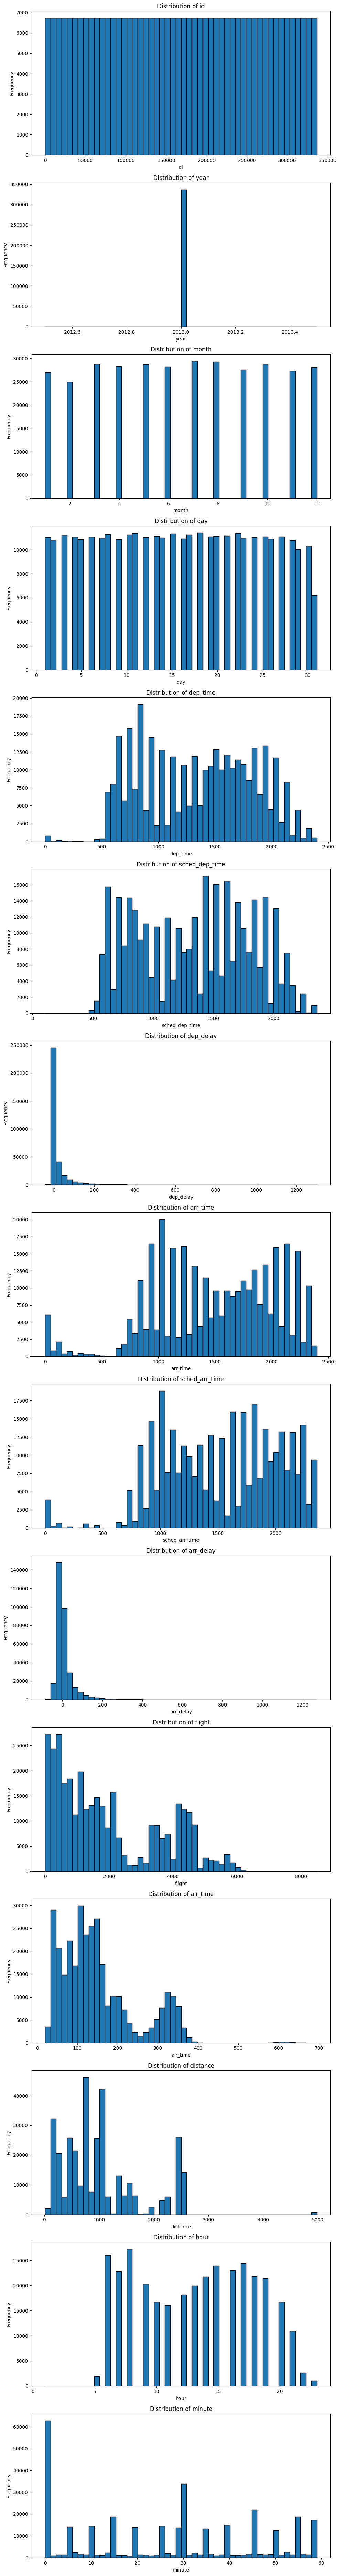

Histograms for numerical features displayed.


In [ ]:
import matplotlib.pyplot as plt

# Identify numerical columns for histograms
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=1, figsize=(10, 5 * len(numerical_cols)))
axes = axes.flatten() # Flatten in case of single row/column

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Histograms for numerical features displayed.")

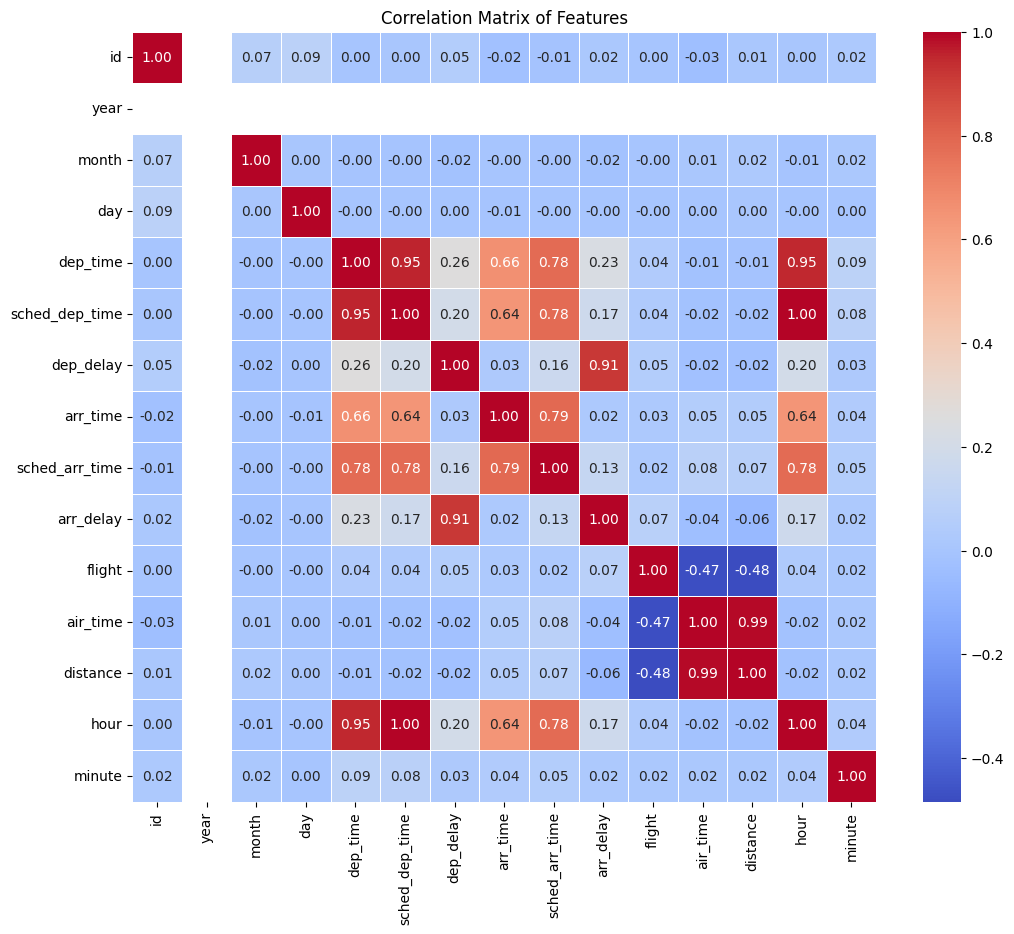

Correlation matrix heatmap displayed.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()
print("Correlation matrix heatmap displayed.")

In [ ]:
print("DataFrame information and data types:")
df.info()

DataFrame information and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              336776 non-null  int64  
 1   year            336776 non-null  int64  
 2   month           336776 non-null  int64  
 3   day             336776 non-null  int64  
 4   dep_time        328521 non-null  float64
 5   sched_dep_time  336776 non-null  int64  
 6   dep_delay       328521 non-null  float64
 7   arr_time        328063 non-null  float64
 8   sched_arr_time  336776 non-null  int64  
 9   arr_delay       327346 non-null  float64
 10  carrier         336776 non-null  object 
 11  flight          336776 non-null  int64  
 12  tailnum         334264 non-null  object 
 13  origin          336776 non-null  object 
 14  dest            336776 non-null  object 
 15  air_time        327346 non-null  float64
 16  distance        33

In [ ]:
X = df.drop('sched_arr_time', axis=1)
y = df['sched_arr_time']

print("Features (X) and target (y) defined.")

Features (X) and target (y) defined.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Redefine X using the already processed df_processed from cell 'cef0d852'
X = df_processed.drop('sched_arr_time', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features (X) scaled using StandardScaler.")

Features (X) scaled using StandardScaler.


In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaled features converted back to DataFrame.")
X_scaled_df.head()

Scaled features converted back to DataFrame.


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,arr_delay,flight,...,dest_SNA,dest_SRQ,dest_STL,dest_STT,dest_SYR,dest_TPA,dest_TUL,dest_TVC,dest_TYS,dest_XNA
0,-1.732046,0.0,-1.625007,-1.677668,-1.727838,-1.774433,-0.258436,-1.278451,0.100748,-0.261520,...,-0.049555,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549
1,-1.732035,0.0,-1.625007,-1.677668,-1.694666,-1.744476,-0.208158,-1.240453,0.305072,-0.157996,...,-0.049555,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549
2,-1.732025,0.0,-1.625007,-1.677668,-1.676006,-1.720938,-0.258436,-1.101761,0.600207,-0.508998,...,-0.049555,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549
3,-1.732015,0.0,-1.625007,-1.677668,-1.671860,-1.710239,-0.333854,-0.947870,-0.557630,-0.763827,...,-0.049555,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549
4,-1.732005,0.0,-1.625007,-1.677668,-1.651127,-1.592551,-0.459550,-1.312649,-0.716549,-0.925545,...,-0.049555,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549


In [ ]:
df_scaled = X_scaled_df.copy()
df_scaled['sched_arr_time'] = y.values
print("Scaled DataFrame 'df_scaled' created with target variable.")
df_scaled.head()

Scaled DataFrame 'df_scaled' created with target variable.


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,arr_delay,flight,...,dest_SRQ,dest_STL,dest_STT,dest_SYR,dest_TPA,dest_TUL,dest_TVC,dest_TYS,dest_XNA,sched_arr_time
0,-1.732046,0.0,-1.625007,-1.677668,-1.727838,-1.774433,-0.258436,-1.278451,0.100748,-0.261520,...,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549,819
1,-1.732035,0.0,-1.625007,-1.677668,-1.694666,-1.744476,-0.208158,-1.240453,0.305072,-0.157996,...,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549,830
2,-1.732025,0.0,-1.625007,-1.677668,-1.676006,-1.720938,-0.258436,-1.101761,0.600207,-0.508998,...,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549,850
3,-1.732015,0.0,-1.625007,-1.677668,-1.671860,-1.710239,-0.333854,-0.947870,-0.557630,-0.763827,...,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549,1022
4,-1.732005,0.0,-1.625007,-1.677668,-1.651127,-1.592551,-0.459550,-1.312649,-0.716549,-0.925545,...,-0.060074,-0.114246,-0.0394,-0.072502,-0.150571,-0.030598,-0.01732,-0.043326,-0.055549,837


Distribution of the target variable 'sched_arr_time':
sched_arr_time
1025    1324
2015    1234
1110    1198
1115    1193
1235    1133
        ... 
103        1
242        1
357        1
146        1
125        1
Name: count, Length: 1163, dtype: int64


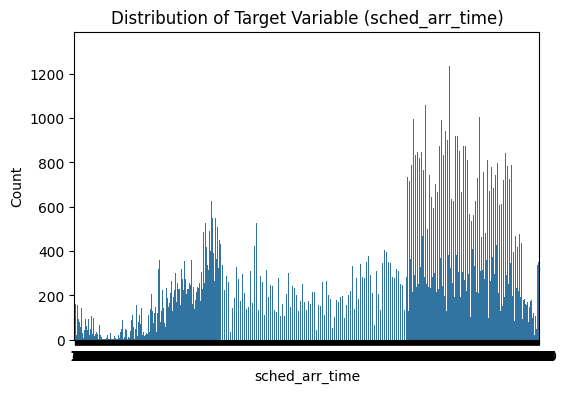

Count plot for 'sched_arr_time' displayed.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Distribution of the target variable 'sched_arr_time':")
print(df_scaled['sched_arr_time'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='sched_arr_time', data=df_scaled)
plt.title('Distribution of Target Variable (sched_arr_time)')
plt.xlabel('sched_arr_time')
plt.ylabel('Count')
plt.show()
print("Count plot for 'sched_arr_time' displayed.")

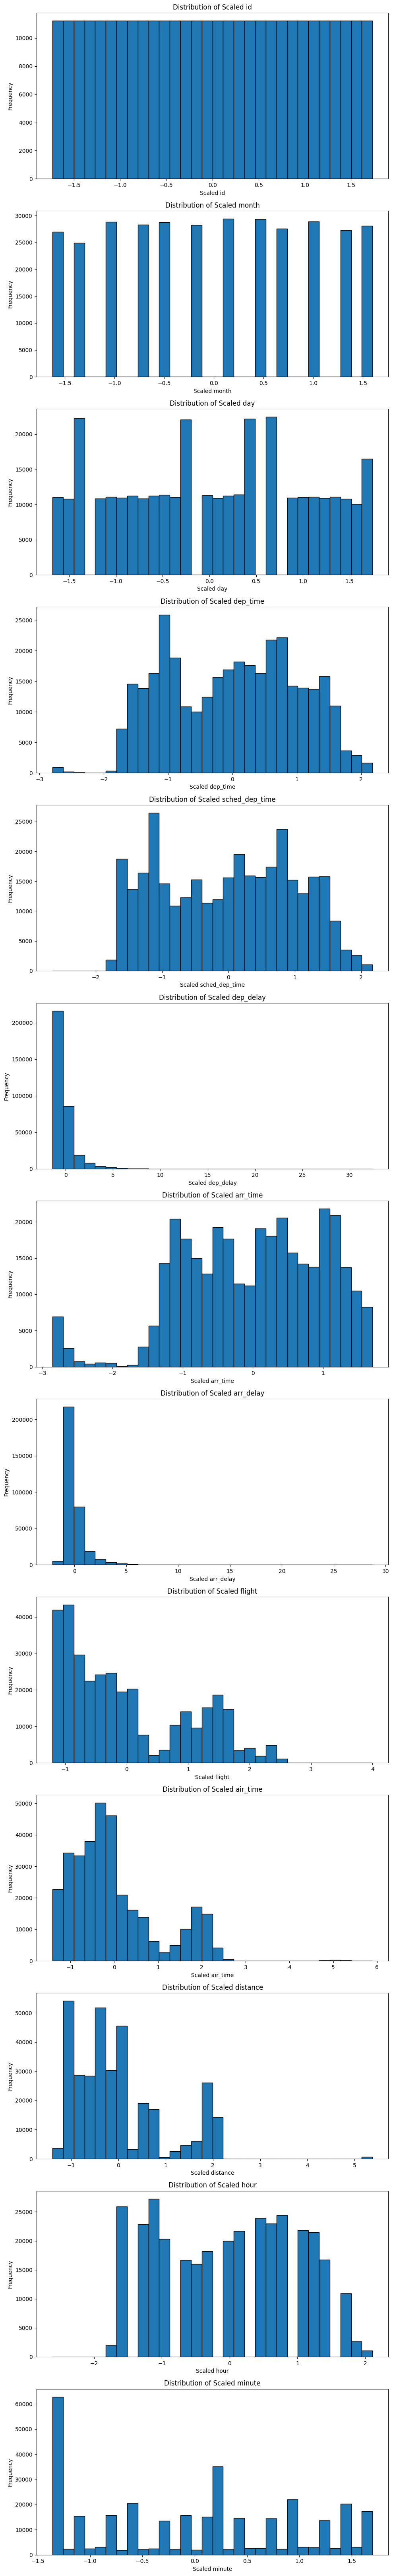

Histograms for selected scaled numerical features displayed.


In [ ]:
numerical_cols_for_hist = [col for col in X_scaled_df.columns if not (
    col.startswith('carrier_') or
    col.startswith('origin_') or
    col.startswith('dest_') or
    X_scaled_df[col].nunique() == 1 # Exclude constant columns
)]

# Adjust nrows based on the filtered columns
fig, axes = plt.subplots(nrows=len(numerical_cols_for_hist), ncols=1, figsize=(10, 5 * len(numerical_cols_for_hist)))
axes = axes.flatten() # Flatten in case of single row/column

if len(numerical_cols_for_hist) == 0:
    print("No suitable numerical columns found for histogram plotting after filtering.")
elif len(numerical_cols_for_hist) == 1:
    # Handle the case where only one plot is generated (axes is not an array)
    col = numerical_cols_for_hist[0]
    axes.hist(X_scaled_df[col], bins=30, edgecolor='black')
    axes.set_title(f'Distribution of Scaled {col}')
    axes.set_xlabel(f'Scaled {col}')
    axes.set_ylabel('Frequency')
else:
    for i, col in enumerate(numerical_cols_for_hist):
        axes[i].hist(X_scaled_df[col], bins=30, edgecolor='black')
        axes[i].set_title(f'Distribution of Scaled {col}')
        axes[i].set_xlabel(f'Scaled {col}')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Histograms for selected scaled numerical features displayed.")

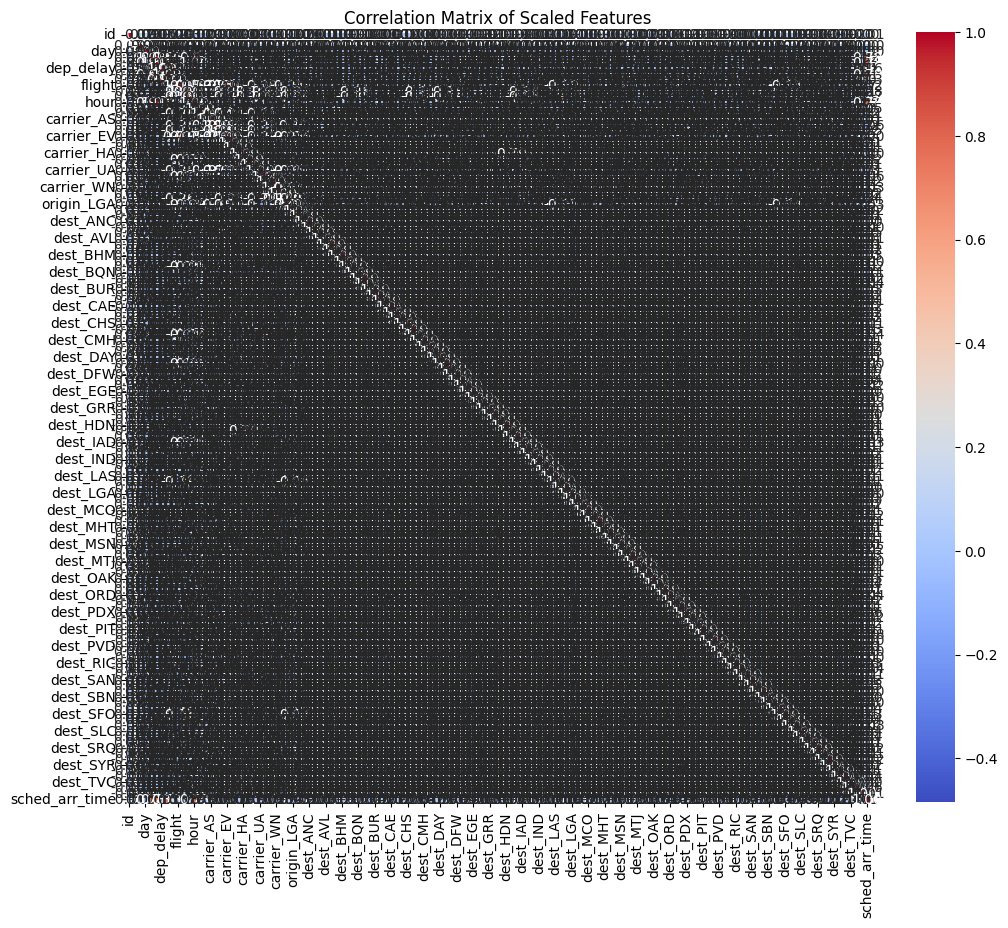

Correlation matrix heatmap for scaled features displayed.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix_scaled = df_scaled.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_scaled, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Scaled Features')
plt.show()
print("Correlation matrix heatmap for scaled features displayed.")

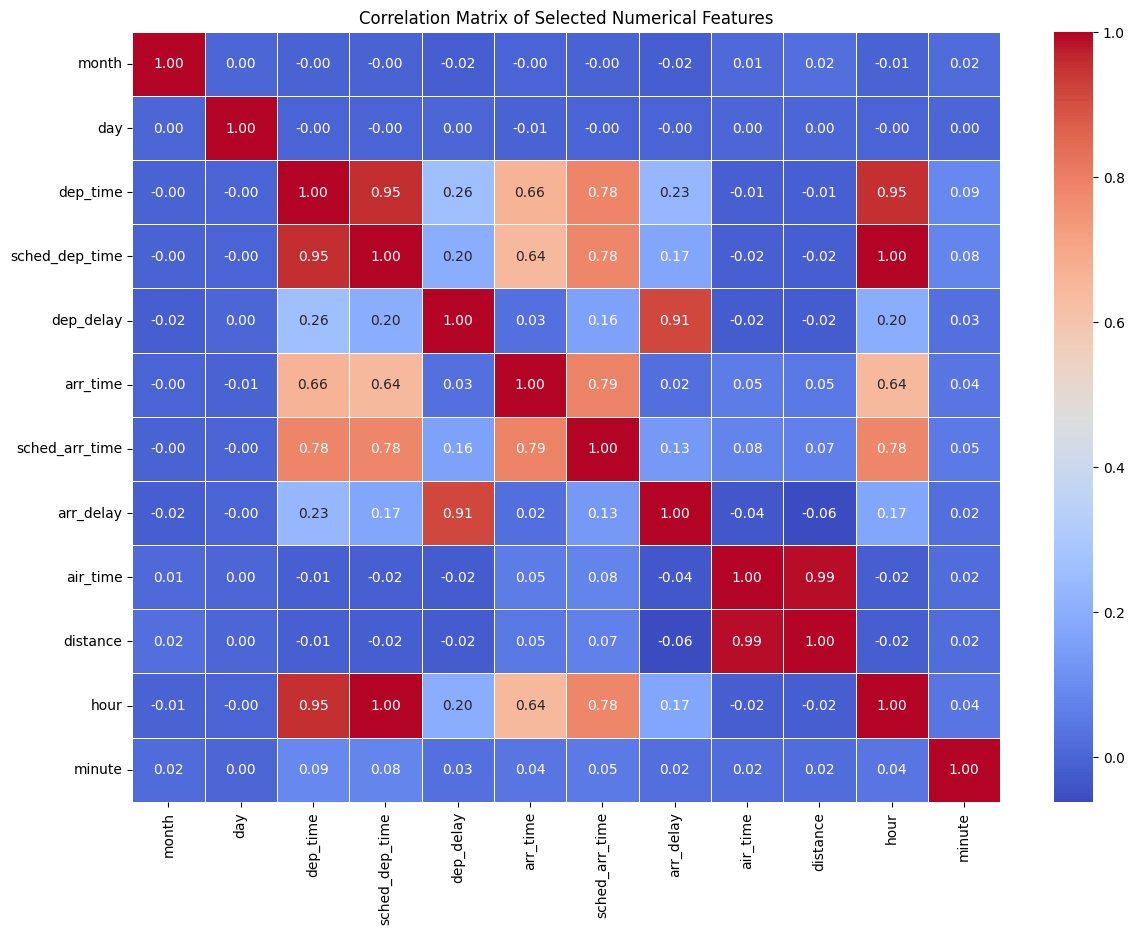

Correlation matrix for selected numerical features displayed.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the relevant numerical columns from the original df
# Exclude 'id' and 'year' as they are constants or identifiers, and not typically used for direct correlation with other features
numerical_features = ['month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
                      'arr_time', 'sched_arr_time', 'arr_delay', 'air_time', 'distance', 'hour', 'minute']

df_numerical_corr = df[numerical_features].copy()

# Calculate the correlation matrix for these selected numerical features
correlation_matrix_numerical = df_numerical_corr.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix_numerical, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Selected Numerical Features')
plt.show()
print("Correlation matrix for selected numerical features displayed.")

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Replace 'data.csv' with your filename
df = pd.read_csv('flights.csv')

# Reapply missing value imputation for dep_time as df was reloaded
df['dep_time'].fillna(df['dep_time'].median(), inplace=True)

# Replace 'X_column' and 'y_column' with your column names
X = df[['dep_time']].values  # For one feature
y = df['sched_arr_time'].values

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# Predict and add predictions as a new column
df['predicted'] = model.predict(X)

print(df.head())

Slope: 0.8005848376578285
Intercept: 455.2849714647614
   id  year  month  day  dep_time  sched_dep_time  dep_delay  arr_time  \
0   0  2013      1    1     517.0             515        2.0     830.0   
1   1  2013      1    1     533.0             529        4.0     850.0   
2   2  2013      1    1     542.0             540        2.0     923.0   
3   3  2013      1    1     544.0             545       -1.0    1004.0   
4   4  2013      1    1     554.0             600       -6.0     812.0   

   sched_arr_time  arr_delay  ... tailnum  origin dest air_time distance  \
0             819       11.0  ...  N14228     EWR  IAH    227.0     1400   
1             830       20.0  ...  N24211     LGA  IAH    227.0     1416   
2             850       33.0  ...  N619AA     JFK  MIA    160.0     1089   
3            1022      -18.0  ...  N804JB     JFK  BQN    183.0     1576   
4             837      -25.0  ...  N668DN     LGA  ATL    116.0      762   

   hour  minute            time_hour       

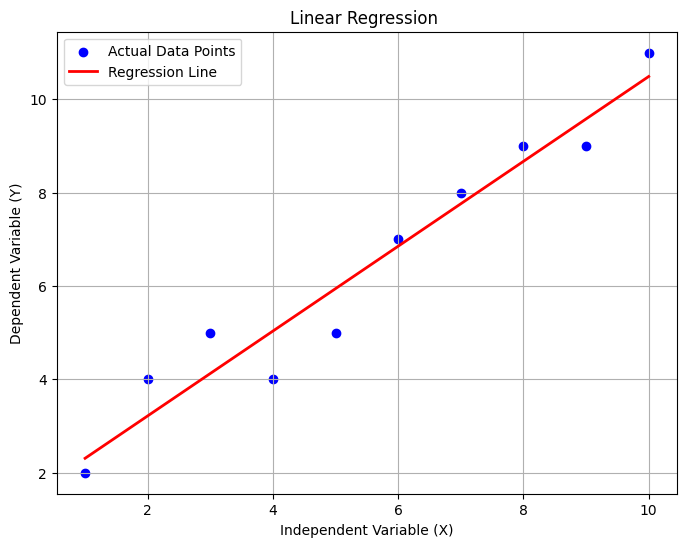

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Sample data
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1) # Independent variable
y = np.array([2, 4, 5, 4, 5, 7, 8, 9, 9, 11]) # Dependent variable
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.figure(figsize=(8, 6)) # Set figure size
plt.scatter(X, y, color='blue', label='Actual Data Points') # Scatter plot of actual data
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line') # Plot the regression line

plt.title('Linear Regression ')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (Y)')
plt.legend()
plt.grid(True)
plt.show()